In [1]:
import numpy as np
import pandas as pd
#Loading Datasets
#Table1-Patient
patient_data = pd.read_csv("C:/Users/parek/Downloads/patients_new.csv")
print("Original Dataset")
patient_data

Original Dataset


,PatientRegNumber,Name,Age,Gender,City,State
0,P001,Anay Shanker,18.0,Other,Bengaluru,Karnataka
1,P002,Nirvaan Choudhury,16.0,Other,Jaipur,Rajasthan
2,P003,Sara Behl,NaN,Male,Pune,Maharashtra
3,NaN,Kiara Kakar,32.0,Male,Delhi,Delhi
4,P005,Aniruddh Batra,8.0,Other,Jaipur,Rajasthan
5,P006,Mehul Krishnan,74.0,Female,Chennai,Tamil Nadu
6,P007,Jhanvi Chaudhary,62.0,Other,Chennai,Tamil Nadu
7,P008,Madhup Kapur,NaN,Male,Kolkata,West Bengal
8,P009,Zoya Virk,48.0,Female,Pune,Maharashtra
9,NaN,Tara Swaminathan,32.0,Female,Bengaluru,Karnataka


In [3]:
#cleaning the patient data - removing the NaN values & deleting duplicates
patient_data=patient_data.dropna()
patient = patient_data.drop_duplicates()
patient.reset_index(drop=True, inplace=True)
patient

,PatientRegNumber,Name,Age,Gender,City,State
0,P001,Anay Shanker,18.0,Other,Bengaluru,Karnataka
1,P002,Nirvaan Choudhury,16.0,Other,Jaipur,Rajasthan
2,P005,Aniruddh Batra,8.0,Other,Jaipur,Rajasthan
3,P006,Mehul Krishnan,74.0,Female,Chennai,Tamil Nadu
4,P007,Jhanvi Chaudhary,62.0,Other,Chennai,Tamil Nadu
5,P009,Zoya Virk,48.0,Female,Pune,Maharashtra
6,P011,Rasha Kakar,16.0,Female,Delhi,Delhi
7,P012,Ranbir Brahmbhatt,50.0,Female,Delhi,Delhi
8,P013,Tarini Ganguly,38.0,Male,Lucknow,Uttar Pradesh
9,P014,Divij Gupta,73.0,Male,Ahmedabad,Gujarat


In [5]:
#Table2-Diagnosis
diagnosis_data=pd.read_csv("C:/Users/parek/Downloads/diagnosis_new.csv")
diagnosis_data

,DiagnosisID,PatientID,TBType,DrugResistanceStatus,Comorbidities
0,DX001,P001,Extrapulmonary,XDR,Diabetes
1,DX002,P002,Pulmonary,XDR,NaN
2,DX003,P003,Extrapulmonary,XDR,Diabetes
3,DX004,P004,Pulmonary,Multidrug,Hepatitis
4,DX005,P005,Pulmonary,Multidrug,NaN
5,DX006,P006,Extrapulmonary,XDR,HIV
6,DX007,P007,Pulmonary,XDR,Diabetes
7,D007,P007,Pulmonary,XDR,Diabetes
8,DX008,P008,Pulmonary,No,Diabetes
9,DX009,P009,Pulmonary,XDR,Malnutrition


In [7]:
#Replacing NaN values in Co-Morbidities column with None
diagnosis = diagnosis_data.fillna("None")
#2 - deleting the row with wrong patientid
diagnosis = diagnosis.drop(7)
#3 - deleting duplicate values
diagnosis = diagnosis.drop_duplicates()
diagnosis.reset_index(drop=True, inplace=True)
diagnosis

,DiagnosisID,PatientID,TBType,DrugResistanceStatus,Comorbidities
0,DX001,P001,Extrapulmonary,XDR,Diabetes
1,DX002,P002,Pulmonary,XDR,None
2,DX003,P003,Extrapulmonary,XDR,Diabetes
3,DX004,P004,Pulmonary,Multidrug,Hepatitis
4,DX005,P005,Pulmonary,Multidrug,None
5,DX006,P006,Extrapulmonary,XDR,HIV
6,DX007,P007,Pulmonary,XDR,Diabetes
7,DX008,P008,Pulmonary,No,Diabetes
8,DX009,P009,Pulmonary,XDR,Malnutrition
9,DX010,P010,Pulmonary,XDR,Diabetes


In [9]:
#Table3-Treatment
treatment_data=pd.read_csv("C:/Users/parek/Downloads/treatment_new.csv")
treatment = treatment_data.drop_duplicates()
treatment = treatment.dropna()
treatment

,TreatmentID,DiagnosisID,Medication,DrugDosage_mg,Duration
0,T001,DX001,HR,269,4
1,T002,DX002,HRE,272,9
2,T003,DX003,HR,485,9
3,T004,DX004,H,419,9
4,T005,DX005,HR,784,9
5,T006,DX006,H,448,6
6,T007,DX007,H,394,4
7,T008,DX008,HRZE,641,6
8,T009,DX009,H,620,6
9,T010,DX010,HRZE,300,4


In [11]:
#Table4-Outcome
outcome_data=pd.read_csv("C:/Users/parek/Downloads/followup_new.csv")
outcome = outcome_data.drop_duplicates()
outcome = outcome.dropna()
outcome

,OutcomeID,PatientID,TreatmentOutcome
0,O001,P001,Cure
1,O002,P002,Cure
2,O003,P003,Loss to follow-up
3,O004,P004,Death
4,O005,P005,Death
5,O006,P006,Treatment failure
6,O007,P007,Death
7,O008,P008,Treatment failure
8,O009,P009,Death
9,O010,P010,Loss to follow-up


In [13]:
#Merging Patient & Diagnosis table - LEFT JOIN
merge1 = pd.merge(patient, diagnosis, left_on='PatientRegNumber', right_on='PatientID', how='left')
merge1.drop(columns=['City','PatientID'], inplace=True)
merge1

,PatientRegNumber,Name,Age,Gender,State,DiagnosisID,TBType,DrugResistanceStatus,Comorbidities
0,P001,Anay Shanker,18.0,Other,Karnataka,DX001,Extrapulmonary,XDR,Diabetes
1,P002,Nirvaan Choudhury,16.0,Other,Rajasthan,DX002,Pulmonary,XDR,None
2,P005,Aniruddh Batra,8.0,Other,Rajasthan,DX005,Pulmonary,Multidrug,None
3,P006,Mehul Krishnan,74.0,Female,Tamil Nadu,DX006,Extrapulmonary,XDR,HIV
4,P007,Jhanvi Chaudhary,62.0,Other,Tamil Nadu,DX007,Pulmonary,XDR,Diabetes
5,P009,Zoya Virk,48.0,Female,Maharashtra,DX009,Pulmonary,XDR,Malnutrition
6,P011,Rasha Kakar,16.0,Female,Delhi,DX011,Extrapulmonary,No,None
7,P012,Ranbir Brahmbhatt,50.0,Female,Delhi,DX012,Extrapulmonary,Multidrug,HIV
8,P013,Tarini Ganguly,38.0,Male,Uttar Pradesh,DX013,Pulmonary,No,Malnutrition
9,P014,Divij Gupta,73.0,Male,Gujarat,DX014,Pulmonary,No,Malnutrition


In [15]:
a = 0
b = 3
while a < len(merge1):
    if merge1.iloc[a,b] == "Other":
        print("Patient:", merge1.iloc[a,1])
        ask = input("Enter the gender - Male / Female")
        if ask == "Male":
            merge1.iloc[a,b] = ask
        else:
            if ask == "Female":
                merge1.iloc[a,b] = ask
            else:
                print("Invalid Entry")
    a = a+1
merge1

Patient: Anay Shanker


Enter the gender - Male / Female Male


Patient: Nirvaan Choudhury


Enter the gender - Male / Female Male


Patient: Aniruddh Batra


...

Patient: Mehul Verma


Enter the gender - Male / Female Male


Patient: Vaibhav Dewan


Enter the gender - Male / Female Male


,PatientRegNumber,Name,Age,Gender,State,DiagnosisID,TBType,DrugResistanceStatus,Comorbidities
0,P001,Anay Shanker,18.0,Male,Karnataka,DX001,Extrapulmonary,XDR,Diabetes
1,P002,Nirvaan Choudhury,16.0,Male,Rajasthan,DX002,Pulmonary,XDR,None
2,P005,Aniruddh Batra,8.0,Male,Rajasthan,DX005,Pulmonary,Multidrug,None
3,P006,Mehul Krishnan,74.0,Female,Tamil Nadu,DX006,Extrapulmonary,XDR,HIV
4,P007,Jhanvi Chaudhary,62.0,Female,Tamil Nadu,DX007,Pulmonary,XDR,Diabetes
5,P009,Zoya Virk,48.0,Female,Maharashtra,DX009,Pulmonary,XDR,Malnutrition
6,P011,Rasha Kakar,16.0,Female,Delhi,DX011,Extrapulmonary,No,None
7,P012,Ranbir Brahmbhatt,50.0,Female,Delhi,DX012,Extrapulmonary,Multidrug,HIV
8,P013,Tarini Ganguly,38.0,Male,Uttar Pradesh,DX013,Pulmonary,No,Malnutrition
9,P014,Divij Gupta,73.0,Male,Gujarat,DX014,Pulmonary,No,Malnutrition


In [17]:
merge1.groupby(["DrugResistanceStatus","Comorbidities"]).groups

{('Multidrug', 'HIV'): [7], ('Multidrug', 'Malnutrition'): [11], ('Multidrug', 'None'): [2, 17], ('No', 'HIV'): [16], ('No', 'Malnutrition'): [8, 9, 12], ('No', 'None'): [6, 19], ('XDR', 'Diabetes'): [0, 4, 13, 14], ('XDR', 'HIV'): [3, 18], ('XDR', 'Hepatitis'): [10, 15], ('XDR', 'Malnutrition'): [5], ('XDR', 'None'): [1]}

In [19]:
i = 0
risk = []
while i < len(merge1):
    if merge1.iloc[i,8]=="HIV":
        r = "High"
        risk.append(r)
    else:
        if merge1.iloc[i,7]=="XDR" and (merge1.iloc[i,8]=="Diabetes" or merge1.iloc[i,8] == "Malnutrition"):
            r = "Moderate"
            risk.append(r)
        else:
            if merge1.iloc[i,7]=="Multidrug" and merge1.iloc[i,8]=="Malnutrition":
                r = "Moderate"
                risk.append(r)
            else:
                r = "Low"
                risk.append(r)
    i = i + 1
merge1["Risk_Classification"]=risk
merge1

,PatientRegNumber,Name,Age,Gender,State,DiagnosisID,TBType,DrugResistanceStatus,Comorbidities,Risk_Classification
0,P001,Anay Shanker,18.0,Male,Karnataka,DX001,Extrapulmonary,XDR,Diabetes,Moderate
1,P002,Nirvaan Choudhury,16.0,Male,Rajasthan,DX002,Pulmonary,XDR,None,Low
2,P005,Aniruddh Batra,8.0,Male,Rajasthan,DX005,Pulmonary,Multidrug,None,Low
3,P006,Mehul Krishnan,74.0,Female,Tamil Nadu,DX006,Extrapulmonary,XDR,HIV,High
4,P007,Jhanvi Chaudhary,62.0,Female,Tamil Nadu,DX007,Pulmonary,XDR,Diabetes,Moderate
5,P009,Zoya Virk,48.0,Female,Maharashtra,DX009,Pulmonary,XDR,Malnutrition,Moderate
6,P011,Rasha Kakar,16.0,Female,Delhi,DX011,Extrapulmonary,No,None,Low
7,P012,Ranbir Brahmbhatt,50.0,Female,Delhi,DX012,Extrapulmonary,Multidrug,HIV,High
8,P013,Tarini Ganguly,38.0,Male,Uttar Pradesh,DX013,Pulmonary,No,Malnutrition,Low
9,P014,Divij Gupta,73.0,Male,Gujarat,DX014,Pulmonary,No,Malnutrition,Low


In [136]:
#Generating Dummy Variables
dummies = pd.get_dummies(outcome, columns=["TreatmentOutcome"], dtype="int")
dummies

,OutcomeID,PatientID,TreatmentOutcome_Cure,TreatmentOutcome_Death,TreatmentOutcome_Loss to follow-up,TreatmentOutcome_Treatment failure
0,O001,P001,1,0,0,0
1,O002,P002,1,0,0,0
2,O003,P003,0,0,1,0
3,O004,P004,0,1,0,0
4,O005,P005,0,1,0,0
5,O006,P006,0,0,0,1
6,O007,P007,0,1,0,0
7,O008,P008,0,0,0,1
8,O009,P009,0,1,0,0
9,O010,P010,0,0,1,0


In [21]:
#Merging Diagnosis & Medication table - RIGHT JOIN
treat_regimen = pd.merge(treatment, diagnosis, left_on='DiagnosisID', right_on='DiagnosisID', how='right')
treat_regimen.drop(columns=['TreatmentID','DiagnosisID'], inplace=True)
treat_regimen = treat_regimen[['PatientID','TBType','DrugResistanceStatus','Medication','DrugDosage_mg',"Comorbidities","Duration"]]
treat_regimen

,PatientID,TBType,DrugResistanceStatus,Medication,DrugDosage_mg,Comorbidities,Duration
0,P001,Extrapulmonary,XDR,HR,269,Diabetes,4
1,P002,Pulmonary,XDR,HRE,272,None,9
2,P003,Extrapulmonary,XDR,HR,485,Diabetes,9
3,P004,Pulmonary,Multidrug,H,419,Hepatitis,9
4,P005,Pulmonary,Multidrug,HR,784,None,9
5,P006,Extrapulmonary,XDR,H,448,HIV,6
6,P007,Pulmonary,XDR,H,394,Diabetes,4
7,P008,Pulmonary,No,HRZE,641,Diabetes,6
8,P009,Pulmonary,XDR,H,620,Malnutrition,6
9,P010,Pulmonary,XDR,HRZE,300,Diabetes,4


In [23]:
#Appending patient information to the Patient table
new_row = pd.DataFrame({"PatientRegNumber":["P026"],"Name":["Vinit Patel"],"Age":[27],"Gender":["Male"],
                        "City":["Mumbai"],"State":["Maharashtra"]})
data = pd.concat([patient,new_row],ignore_index=True)
data

,PatientRegNumber,Name,Age,Gender,City,State
0,P001,Anay Shanker,18.0,Other,Bengaluru,Karnataka
1,P002,Nirvaan Choudhury,16.0,Other,Jaipur,Rajasthan
2,P005,Aniruddh Batra,8.0,Other,Jaipur,Rajasthan
3,P006,Mehul Krishnan,74.0,Female,Chennai,Tamil Nadu
4,P007,Jhanvi Chaudhary,62.0,Other,Chennai,Tamil Nadu
5,P009,Zoya Virk,48.0,Female,Pune,Maharashtra
6,P011,Rasha Kakar,16.0,Female,Delhi,Delhi
7,P012,Ranbir Brahmbhatt,50.0,Female,Delhi,Delhi
8,P013,Tarini Ganguly,38.0,Male,Lucknow,Uttar Pradesh
9,P014,Divij Gupta,73.0,Male,Ahmedabad,Gujarat


In [25]:
#Statistical Report 1
tbtype = diagnosis["TBType"].value_counts()
print("Count of patients for each TB Type")
print(tbtype)
print("")
print("STATISTICAL REPORT - 1")
p = (tbtype["Pulmonary"]/tbtype.sum()) * 100
print("% of patients with Pulmonary TB:",p)
p = (tbtype["Extrapulmonary"]/tbtype.sum()) * 100
print("% of patients with Extra-Pulmonary TB:",p)

Count of patients for each TB Type
TBType
Pulmonary         17
Extrapulmonary     8
Name: count, dtype: int64

STATISTICAL REPORT - 1
% of patients with Pulmonary TB: 68.0
% of patients with Extra-Pulmonary TB: 32.0


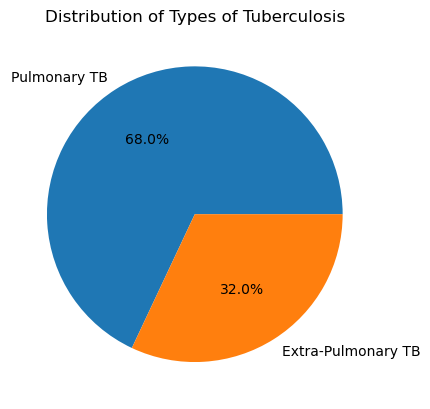

In [27]:
#Vizualisation - 1
import matplotlib.pyplot as plt
labels = ["Pulmonary TB", "Extra-Pulmonary TB"]
plt.pie(tbtype,labels = labels,autopct='%1.1f%%')
plt.title("Distribution of Types of Tuberculosis")
plt.show()

In [29]:
#Statistical Report - 2
avg_dose = treat_regimen.groupby("DrugResistanceStatus")["DrugDosage_mg"].mean()
print(avg_dose)

DrugResistanceStatus
Multidrug    597.000000
No           521.428571
XDR          507.615385
Name: DrugDosage_mg, dtype: float64


In [31]:
#Statistical Report - 3
new_data = pd.merge(patient,outcome, left_on='PatientRegNumber', right_on='PatientID', how='left')
new_data.drop(columns=['Name','Gender','OutcomeID','PatientID'], inplace=True)
out = new_data.groupby(['State', 'TreatmentOutcome']).size()
out

State          TreatmentOutcome 
Delhi          Death                1
               Treatment failure    1
Gujarat        Death                1
Karnataka      Cure                 2
Maharashtra    Death                1
Rajasthan      Cure                 1
               Death                1
Tamil Nadu     Cure                 2
               Death                1
               Loss to follow-up    1
               Treatment failure    2
Telangana      Death                1
               Treatment failure    1
Uttar Pradesh  Loss to follow-up    1
West Bengal    Cure                 1
               Death                1
               Treatment failure    1
dtype: int64

In [33]:
#Statistical Report - 4
print("The minimum value of drug dose of HRZE used is:", 
      treat_regimen[treat_regimen["Medication"] == "HRZE"]["DrugDosage_mg"].min())

The minimum value of drug dose of HRZE used is: 300


In [35]:
#Statistical Report - 5
print("The maximum value of drug dose of HRZE used is:", 
      treat_regimen[treat_regimen["Medication"] == "HRZE"]["DrugDosage_mg"].max())

The maximum value of drug dose of HRZE used is: 753


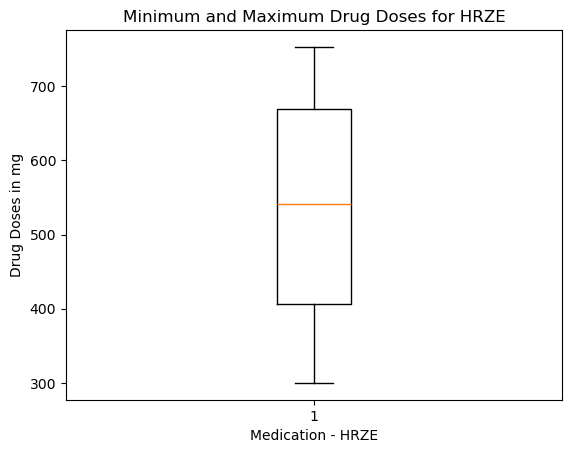

In [37]:
#Vizualisation -3 Box Plot
plt.boxplot(treat_regimen[treat_regimen["Medication"]== "HRZE"]["DrugDosage_mg"])
plt.xlabel("Medication - HRZE")
plt.ylabel("Drug Doses in mg")
plt.title("Minimum and Maximum Drug Doses for HRZE")
plt.show()

In [39]:
#Checking for Normality of Data
from scipy.stats import normaltest
print(normaltest(merge1["Age"]))
print("Skewness:",merge1["Age"].skew())
print("Kurtosis:",merge1["Age"].kurtosis())

NormaltestResult(statistic=4.755866561652655, pvalue=0.09274205135659903)
Skewness: 0.3637873802746995
Kurtosis: -1.3317880209559498


In [41]:
#T-test
from scipy.stats import ttest_ind
pulm = merge1[merge1["TBType"]=="Pulmonary"]["Age"]
ex_p = merge1[merge1["TBType"]=="Extrapulmonary"]["Age"]
test=ttest_ind(pulm,ex_p)
print(test)

TtestResult(statistic=-0.46899521057182075, pvalue=0.6447034507755471, df=18.0)


In [43]:
#Corelation
final = pd.merge(treat_regimen,patient,left_on='PatientID',right_on="PatientRegNumber", how='right')
corr_matrix1=final[["Age","DrugDosage_mg"]].corr()
corr_matrix1

,Age,DrugDosage_mg
Age,1.000000,-0.147039
DrugDosage_mg,-0.147039,1.000000


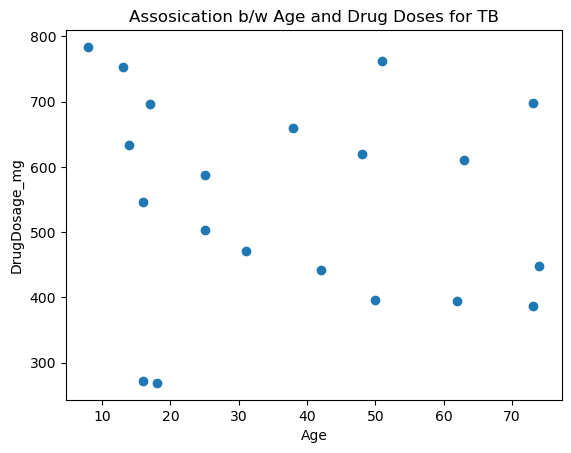

In [45]:
#Vizualisation -2 Scatter Plot
plt.scatter(final["Age"],final["DrugDosage_mg"])
plt.xlabel("Age")
plt.ylabel("DrugDosage_mg")
plt.title("Assosication b/w Age and Drug Doses for TB")
plt.show()

In [306]:
#Linear Regression
import statsmodels.api as sm
from statsmodels.formula.api import ols
f = pd.merge(treat_regimen,data,left_on="PatientID",right_on="PatientRegNumber",how="left")
model = ols('DrugDosage_mg ~ Age + C(Comorbidities)', data=f)
results = model.fit()
print(results.summary())
print(f)

                            OLS Regression Results                            
Dep. Variable:          DrugDosage_mg   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                 -0.175
Method:                 Least Squares   F-statistic:                    0.4343
Date:                Wed, 30 Apr 2025   Prob (F-statistic):              0.817
Time:                        21:43:11   Log-Likelihood:                -127.68
No. Observations:                  20   AIC:                             267.4
Df Residuals:                      14   BIC:                             273.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

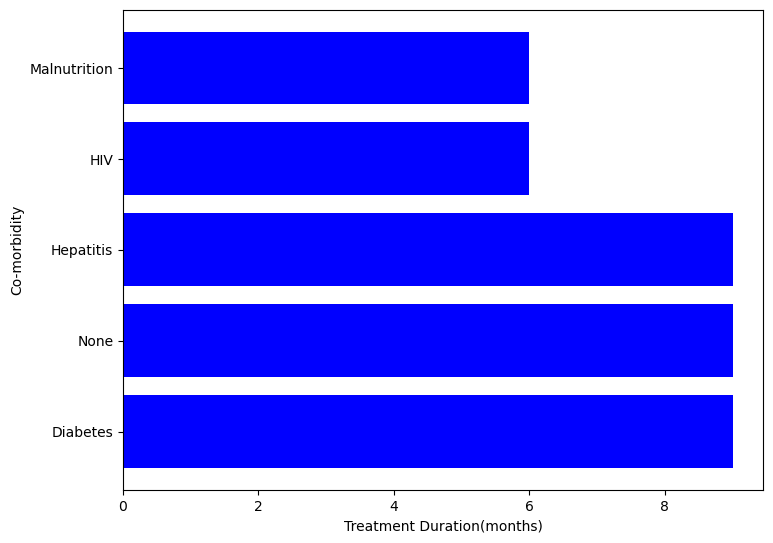

In [47]:
#Vizualisation - 4 Bar chart
fig = plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.barh(treat_regimen["Comorbidities"],treat_regimen["Duration"],color='b')
plt.ylabel("Co-morbidity")
plt.xlabel("Treatment Duration(months)")
plt.show()